# DEG analysis between converters, non-converters and HC at baseline
- related to Fig S4CD

In [5]:
# load libraries
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("lubridate")
quiet_library("ggplot2")
quiet_library("ggpubr")
quiet_library("lme4")
quiet_library("Matrix")
quiet_library("DESeq2")
quiet_library("SingleCellExperiment")
quiet_library("data.table")
quiet_library("rstatix")
quiet_library("circlize")
quiet_library("ComplexHeatmap")

Warning message:
“package ‘purrr’ was built under R version 4.4.2”
Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
Warning message:
“package ‘Matrix’ was built under R version 4.4.3”
Warning message in check_dep_version():
“ABI version mismatch: 
lme4 was built with Matrix ABI version 1
Current Matrix ABI version is 2
Please re-install lme4 from source or restore original ‘Matrix’ package”
Warning message:
“package ‘DESeq2’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘IRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.4.2”
Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Warning message:
“package ‘MatrixGenerics’ was built under R version 4.

In [6]:
source("/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r")

In [7]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")

In [8]:
# define path
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/AIFIL2_crox_allgroups/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/AIFIL2_crox_allgroups"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name <- "ALTRA_L2_baseline_crox_"

## load pseudobulk data

In [9]:
hise::cacheFiles(list("d9ced8ed-5954-4347-91e0-2415eed5d085"))

[1] "downloading fileID d9ced8ed-5954-4347-91e0-2415eed5d085"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/d9ced8ed-5954-4347-91e0-2415eed5d085/revision/ALTRA_scRNA_AIFI_L2_141samples__psedobulk_SE_object_list.rds"

In [10]:
# load pseudobulk data for all 141 samples
pd_se <- readRDS(
  "/home/workspace/input/569004694/UCSDCU_Y4/d9ced8ed-5954-4347-91e0-2415eed5d085/revision/ALTRA_scRNA_AIFI_L2_141samples__psedobulk_SE_object_list.rds"
)

In [11]:
names(pd_se)

[1] "ASDC"                  "CD14 monocyte"         "CD16 monocyte"        
 [4] "CD56bright NK cell"    "CD56dim NK cell"       "CD8aa"                
 [7] "DN T cell"             "Effector B cell"       "Erythrocyte"          
[10] "ILC"                   "Intermediate monocyte" "MAIT"                 
[13] "Memory B cell"         "Memory CD4 T cell"     "Memory CD8 T cell"    
[16] "Naive B cell"          "Naive CD4 T cell"      "Naive CD8 T cell"     
[19] "Plasma cell"           "Platelet"              "Progenitor cell"      
[22] "Proliferating NK cell" "Proliferating T cell"  "Transitional B cell"  
[25] "Treg"                  "cDC1"                  "cDC2"                 
[28] "gdT"                   "pDC"

In [12]:
colData(pd_se[["Naive CD4 T cell"]])$sample.sampleKitGuid %>% length()

[1] 141

# compare baseline  converters vs non-converters vs ERA

In [14]:
# load metadata for sample selection
altra_meta <- read_csv("/home/workspace/github/ra-longitudinal/metadata/2023-11-22_ALTRA_Metadata_labs.csv",
  show_col_types = FALSE
)
scrna_sample <- read_csv("/home/workspace/github/ra-longitudinal/metadata/ALTRA_scRNA_combined_141_samples_info.csv",
  show_col_types = FALSE
)
# only keep sample that has scrna data
altra_meta <- altra_meta %>% filter(sample.sampleKitGuid %in% scrna_sample$sample.sampleKitGuid)
altra_meta %>% dim()

New names:
• `record_id...112` -> `record_id...128`
• `record_id...120` -> `record_id...136`
• `record_id...114` -> `record_id...140`
• `record_id...123` -> `record_id...141`


[1] 141 148

In [15]:
# load aim 1 and aim2 metadata
aim1_meta <- read_csv("/home/workspace/github/ra-longitudinal/metadata/ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv",
  show_col_types = FALSE
)
aim2_meta <- read_csv("/home/workspace/github/ra-longitudinal/metadata/ALTRA_RA_Aim2_ALTRA_early_RA_vs_HCs_scrna_metadata.csv",
  show_col_types = FALSE
)

In [16]:
altra_meta %>%
  group_by(Status_Xsec, Status_Long) %>%
  tally()

Status_Xsec,Status_Long,n
<chr>,<chr>,<int>
ALTRA_healthy,NA,31
at_risk,pre,14
at_risk,NA,31
early_RA,conversion,11
early_RA,pre,1
early_RA,NA,13
NA,pre,40


In [17]:
# baseline_altra = altra_meta%>% group_by(subject.subjectGuid)%>% slice_min(order_by = sample.daysSinceFirstVisit)
# table(aim1_meta$sample.sampleKitGuid%in% baseline_altra$sample.sampleKitGuid)

In [18]:
# select the crossectional comparison sample for converters non-converters, HC, early RA
crox_altra <- altra_meta %>%
  filter(subject.subjectGuid != "CU1002") %>%
  filter(sample.sampleKitGuid %in% aim1_meta$sample.sampleKitGuid | sample.sampleKitGuid %in% aim2_meta$sample.sampleKitGuid) %>%
  filter(!(Status_Xsec == "early_RA" & Status_Long %in% c("conversion", "pre"))) %>%
  mutate(
    status_converter = case_when(
      Status_Xsec == "at_risk" & Status_Long == "pre" ~ "converter",
      Status_Xsec == "at_risk" & is.na(Status_Long) ~ "non_converter",
      TRUE ~ Status_Xsec
    ),
    day_to_conv_curr = case_when(
      status_converter %in% c("ALTRA_healthy", "non_converter") ~ as.numeric(as_date(sample.drawDate) - as_date("2024-06-01")),
      status_converter == "converter" ~ days_to_conversion,
      status_converter == "early_RA" ~ numof_days_to_from_ia_conversion
    ),
    rfigm_result = if_else(rfigm_result == 999, NA, rfigm_result)
  ) %>%
  group_by(subject.subjectGuid) %>%
  slice_min(order_by = sample.daysSinceFirstVisit) %>%
  ungroup() %>%
  mutate(status = factor(recode(status_converter, "ALTRA_healthy" = "HC", "non_converter" = "NONC", "converter" = "CONV", "early_RA" = "ERA"), levels = c("HC", "NONC", "CONV", "ERA")))
crox_altra %>%
  group_by(status) %>%
  tally()

status,n
<fct>,<int>
HC,31
NONC,30
CONV,14
ERA,11


In [19]:
crox_altra %>% write_csv(file.path(output_path, paste0(proj_name, "_scrna_metadata.csv")))

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


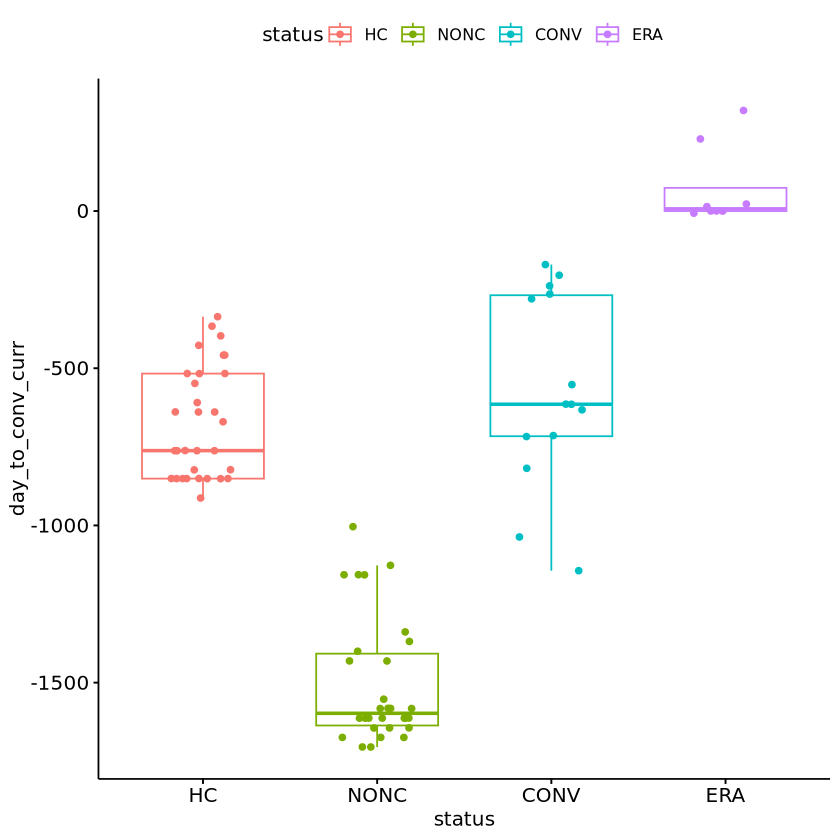

In [20]:
ggpubr::ggboxplot(crox_altra, x = "status", y = "day_to_conv_curr", color = "status", add = "jitter")
ggsave(file.path(fig_path, paste0(proj_name, "days_to_conversion.png")), width = 5, height = 5)

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_signif()`).”
Warning message in wilcox.test.default(c(6, 4, 6, 8, 5, 6, 6, 6, 6, 6, 6, 6, 6, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(99, 32, 195, 24, 269, 52, 195, 120, 56, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(262, 2544, 88, 384, 22, 42, 1557, 56, 51, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_signif()`).”
Warning message i

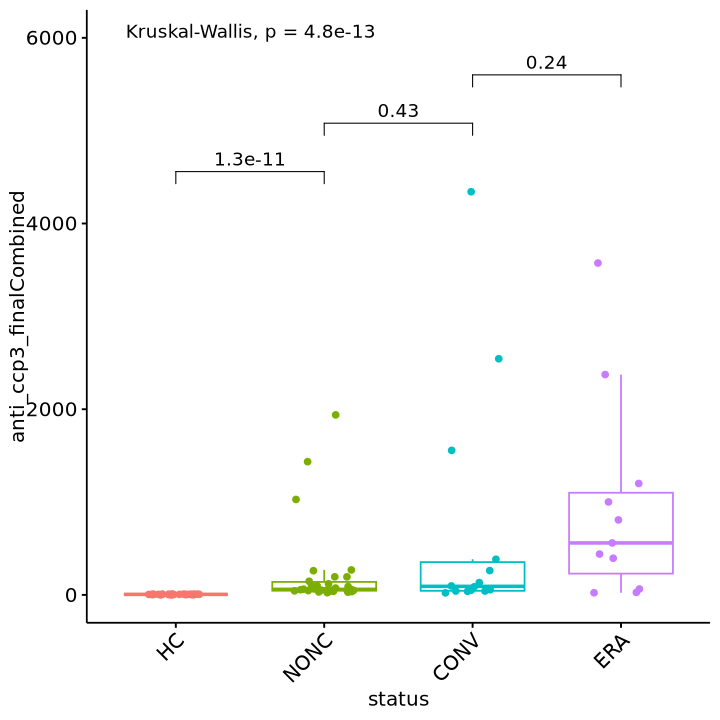

In [21]:
options(repr.plot.width = 6, repr.plot.height = 6)
my_comparisons <- list(c("HC", "NONC"), c("NONC", "CONV"), c("CONV", "ERA"))
p1 <- crox_altra %>% ggboxplot(
  x = "status", y = "anti_ccp3_finalCombined", # yscale='log10',
  color = "status", add = "jitter"
) +
  theme(legend.position = "none") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  stat_compare_means(comparisons = my_comparisons) + # Add pairwise comparisons p-value
  stat_compare_means(label.y = 6000)
p1
ggsave(file.path(fig_path, paste0(proj_name, "CCP3.png")), width = 5, height = 5)
# p2<-crox_altra%>%ggboxplot(x='status', y='rfigm_result', #yscale='log10',
#                       color='status', add='jitter')+
#   theme(legend.position="none")+
#   theme(axis.text.x = element_text(angle = 45, hjust = 1))
# p3<-crox_altra%>%ggboxplot(x='status', y='rfiga_result', #yscale='log10',
#                       color='status', add='jitter')+
#   theme(legend.position="none")+
#   theme(axis.text.x = element_text(angle = 45, hjust = 1))
# cowplot::plot_grid(p1, p2, p3, nrow = 1)
# ggsave(file.path(fig_path, paste0(proj_name, 'autoabs.png')), width = 12, height = 6)

Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message in wilcox.test.default(c(5, 0.25, 40.35, 5.17, 17.35, 5, 5, 5, 5, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.25, 2.4, 0.25, 6.77, 1.76, 0.25, 104.75, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(26.56, 104.75, 25.76, 0.25, 0.25, 16.09, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning

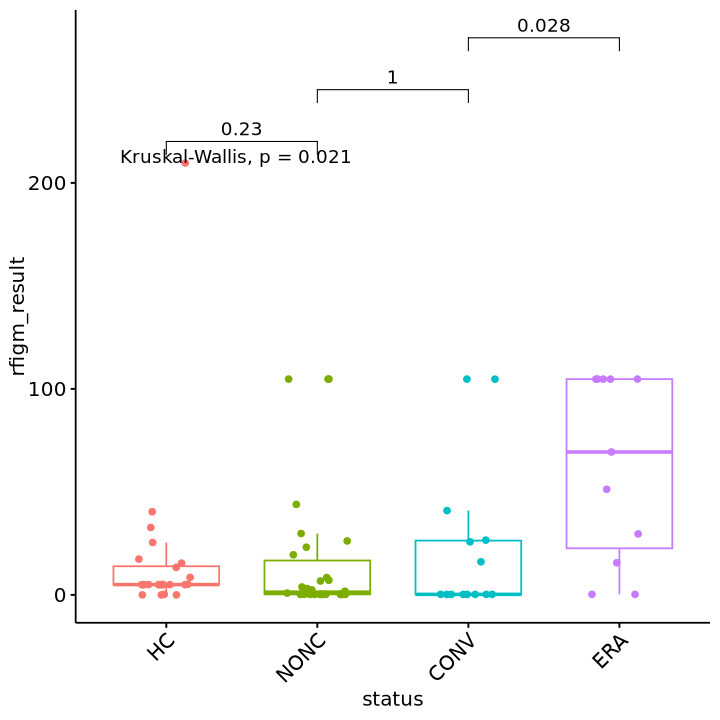

In [22]:
p2 <- crox_altra %>% ggboxplot(
  x = "status", y = "rfigm_result", # yscale='log10',
  color = "status", add = "jitter"
) +
  theme(legend.position = "none") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  stat_compare_means(comparisons = my_comparisons) + # Add pairwise comparisons p-value
  stat_compare_means()
p2
ggsave(file.path(fig_path, paste0(proj_name, "rfigm.png")), width = 5, height = 5)

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message in wilcox.test.default(c(1.7, 0.25, 1.7, 0.25, 0.25, 1.7, 1.7, 1.7, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 12.11, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.25, 65.77, 0.25, 5.19, 0.25, 2.95, 7.32, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_signif()`).”
War

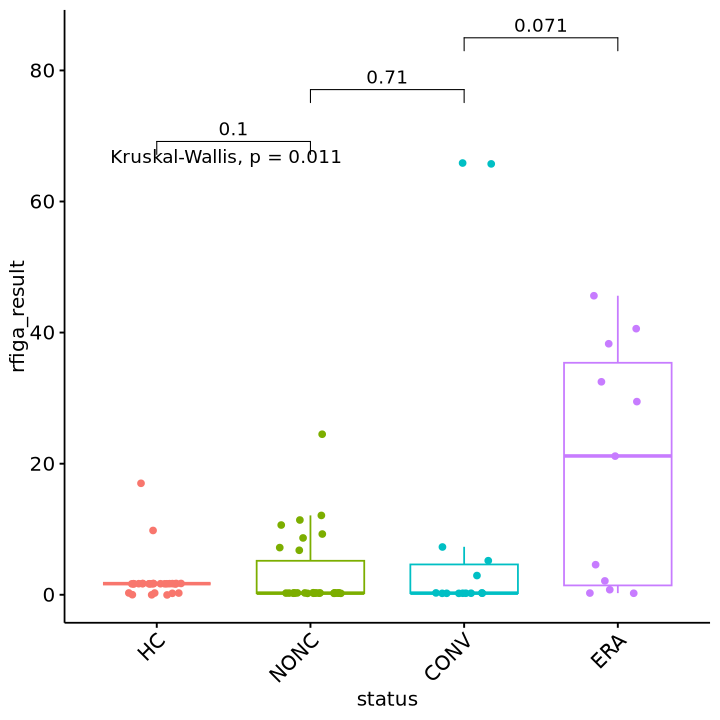

In [23]:
p2 <- crox_altra %>% ggboxplot(
  x = "status", y = "rfiga_result", # yscale='log10',
  color = "status", add = "jitter"
) +
  theme(legend.position = "none") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  stat_compare_means(comparisons = my_comparisons) + # Add pairwise comparisons p-value
  stat_compare_means()
p2
ggsave(file.path(fig_path, paste0(proj_name, "rfiga.png")), width = 5, height = 5)

In [24]:
crox_altra %>% kruskal_test(formula = rfigm_result ~ status)
pairwise_result <- crox_altra %>%
  dunn_test(
    rfigm_result ~ status,
    p.adjust.method = "BH" # Adjust p-values for multiple comparisons
  )
pairwise_result

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
Kruskal-Wallis chi-squared,rfigm_result,86,9.764385,3,0.0207,Kruskal-Wallis


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rfigm_result,HC,NONC,24,30,-0.8928301,0.371948173,0.55792226,ns
2,rfigm_result,HC,CONV,24,14,-0.4784814,0.632307590,0.75876911,ns
3,rfigm_result,HC,ERA,24,11,2.2844684,0.022344017,0.04468803,*
4,rfigm_result,NONC,CONV,30,14,0.2582883,0.796184415,0.79618442,ns
5,rfigm_result,NONC,ERA,30,11,3.0535269,0.002261685,0.01357011,*
6,rfigm_result,CONV,ERA,14,11,2.4638372,0.013745852,0.04123756,*


# run degs analysis in all groups

In [25]:
# subset pseudobulk data
pb_se_crox <- lapply(pd_se, function(pb, meta = crox_altra) {
  # select samples
  pb <- pb[, colData(pb)$sample.sampleKitGuid %in% meta$sample.sampleKitGuid]
  # add status_converter column
  colData(pb) <- colData(pb) %>%
    as.data.frame() %>%
    merge(select(meta, c(sample.sampleKitGuid, status_converter)),
      by = "sample.sampleKitGuid", all.x = TRUE
    ) %>%
    DataFrame()
  return(pb)
})

In [26]:
colData(pb_se_crox[["Naive CD4 T cell"]]) %>%
  as_tibble() %>%
  group_by(status_converter, status, Status_Xsec) %>%
  tally()

status_converter,status,Status_Xsec,n
<chr>,<chr>,<chr>,<int>
ALTRA_healthy,ALTRA_healthy,ALTRA_healthy,31
converter,at_risk,at_risk,14
early_RA,early_RA,early_RA,11
non_converter,at_risk,at_risk,30


In [27]:
# check the samples numbers
count_status <- function(x, celltype_col = "AIFI_L2", group_col = "status_converter") {
  sample_counts <- colData(x) %>%
    as_tibble() %>%
    group_by(.data[[group_col]]) %>%
    reframe(
      sample_number = n(),
      cell_type = unique(.data[[celltype_col]])
    )
  return(sample_counts)
}

# Applying the function to each SCE object in the list
status_counts <- lapply(pb_se_crox, count_status) %>%
  data.table::rbindlist() %>%
  pivot_wider(
    id_cols = "cell_type", names_from = "status_converter",
    values_from = "sample_number", values_fill = 0
  )
status_counts

cell_type,ALTRA_healthy,converter,non_converter,early_RA
<chr>,<int>,<int>,<int>,<int>
ASDC,1,1,1,0
CD14 monocyte,31,14,30,11
CD16 monocyte,31,14,30,11
CD56bright NK cell,31,14,30,11
CD56dim NK cell,31,14,30,11
CD8aa,10,6,7,1
DN T cell,26,14,29,10
Effector B cell,30,14,29,11
Erythrocyte,25,6,18,6


In [28]:
# selecting celltypes that has atleast 5 at-risk samples and 5 HC samples
status_counts_fl <- status_counts %>% filter(converter >= 3 & non_converter >= 3 & ALTRA_healthy >= 5)
cell_types_to_keep <- status_counts_fl %>% pull(cell_type)
cell_types_to_keep %>% length()
cell_types_to_keep

[1] 27

[1] "CD14 monocyte"         "CD16 monocyte"         "CD56bright NK cell"   
 [4] "CD56dim NK cell"       "CD8aa"                 "DN T cell"            
 [7] "Effector B cell"       "Erythrocyte"           "Intermediate monocyte"
[10] "MAIT"                  "Memory B cell"         "Memory CD4 T cell"    
[13] "Memory CD8 T cell"     "Naive B cell"          "Naive CD4 T cell"     
[16] "Naive CD8 T cell"      "Plasma cell"           "Platelet"             
[19] "Progenitor cell"       "Proliferating NK cell" "Proliferating T cell" 
[22] "Transitional B cell"   "Treg"                  "cDC1"                 
[25] "cDC2"                  "gdT"                   "pDC"

In [29]:
length(pb_se_crox)

[1] 29

In [30]:
# use the same 67 cells type in the original analysis
subset_pb_se_crox <- pb_se_crox[names(pb_se_crox) %in% cell_types_to_keep]

In [31]:
length(subset_pb_se_crox)

[1] 27

# run deseq2

In [36]:
# set up the data to run deseq2
## B182 had dominant batch effect and need to adjust
subset_pb_se_crox <- lapply(subset_pb_se_crox, function(pb) {
  # remove CU1002
  pb <- pb[, colData(pb)$subject.subjectGuid != "CU1002"]
  # remove early RA
  pb <- pb[, colData(pb)$status_converter != "early_RA"]
  # format metadata
  pb$batch_corr <- ifelse(pb$file.batchID == "B182", "B182", "other_batches")
  # Modify disease category in coldata and convert to factor
  # Assuming 'status' is the column you want to modify
  pb$file.batchID <- factor(pb$file.batchID)
  pb$status_converter <- factor(pb$status_converter, levels = c("ALTRA_healthy", "non_converter", "converter"))
  pb$batch_corr <- factor(pb$batch_corr, levels = c("other_batches", "B182"))
  pb$subject.biologicalSex <- factor(pb$subject.biologicalSex, levels = c("Female", "Male"))
  pb$age <- lubridate::year(lubridate::as_date(pb$sample.drawDate)) - as.numeric(pb$subject.birthYear)
  pb$scale_age <- scale(pb$age)
  pb$scale_bmi <- scale(pb$BMI)
  return(pb)
})

# compare conv vs nonc only

In [32]:
## remove Batch182
pb_se_conv_nonc <- lapply(subset_pb_se_crox, function(pb) {
  # remove CU1002
  pb <- pb[, colData(pb)$subject.subjectGuid != "CU1002"]
  pb <- pb[, colData(pb)$status_converter %in% c("non_converter", "converter")]
  # format metadata
  pb$batch_corr <- ifelse(pb$file.batchID == "B182", "B182", "other_batches")
  # Modify disease category in coldata and convert to factor
  # Assuming 'status' is the column you want to modify
  pb$Status_Xsec <- factor(pb$Status_Xsec, levels = c("ALTRA_healthy", "at_risk"))
  pb$status_converter <- factor(pb$status_converter, levels = c("ALTRA_healthy", "non_converter", "converter", "early_RA"))
  pb$batch_corr <- factor(pb$batch_corr, levels = c("other_batches", "B182"))
  pb$file.batchID <- factor(pb$file.batchID)
  pb$subject.biologicalSex <- factor(pb$subject.biologicalSex, levels = c("Female", "Male"))
  pb$age <- lubridate::year(lubridate::as_date(pb$sample.drawDate)) - as.numeric(pb$subject.birthYear)
  pb$scale_age <- scale(pb$age)
  pb$scale_bmi <- scale(pb$BMI)
  return(pb)
})

In [95]:
# run deseq to do deg analysis
formula <- "~ scale_age + scale_bmi + subject.biologicalSex + file.batchID + status_converter"
deseq_conv_nonc <- RunDeseq_list(pb_se_conv_nonc, formula)

run Deseq2 for cell type CD14 monocyte

converting counts to integer mode

factor levels were dropped which had no samples

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

2 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

run Deseq2 for cell type CD16 monocyte

converting counts to integer mode

factor levels were dropped which had no samples

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

5 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

run Deseq2 for cell type CD56bright NK cell

converting counts to integer mode

factor levels were dropped which had no samples

estimating size factors

estimating dispersions

gene-wise 

In [ ]:
deseq_conv_nonc %>% saveRDS(file.path(output_path, paste0(proj_name, "_deseq2_object_conv_nonv.rds")))

In [4]:
deseq_conv_nonc <- readRDS(file.path(output_path, paste0(proj_name, "_deseq2_object_conv_nonv.rds")))

In [41]:
# remove cd8aa; rare cell type
pb_se_conv_nonc <- pb_se_conv_nonc[names(pb_se_conv_nonc) != "CD8aa"]
deseq_conv_nonc <- deseq_conv_nonc[names(deseq_conv_nonc) != "CD8aa"]

In [42]:
# add deseq normalized count to the se objects
conv_nonc_norm <- addNormcountsList(pb_se_conv_nonc, deseq_conv_nonc,
  method = "vst",
  assay_name = "normalized_counts"
)

Add normalized counts for CD14 monocyte

Add normalized counts for CD16 monocyte

Add normalized counts for CD56bright NK cell

Add normalized counts for CD56dim NK cell

Add normalized counts for DN T cell

Add normalized counts for Effector B cell

Add normalized counts for Erythrocyte

Add normalized counts for Intermediate monocyte

Add normalized counts for MAIT

Add normalized counts for Memory B cell

Add normalized counts for Memory CD4 T cell

Add normalized counts for Memory CD8 T cell

Add normalized counts for Naive B cell

Add normalized counts for Naive CD4 T cell

Add normalized counts for Naive CD8 T cell

Add normalized counts for Plasma cell

Add normalized counts for Platelet

Add normalized counts for Progenitor cell

Add normalized counts for Proliferating NK cell

Add normalized counts for Proliferating T cell

Add normalized counts for Transitional B cell

Add normalized counts for Treg

Add normalized counts for cDC1

Add normalized counts for cDC2

Add normaliz

In [48]:
conv_nonc_norm %>% saveRDS(file.path(output_path, paste0(proj_name, "_conv_nonv_deseq2_norm_counts.rds")))

## analyze DEG results

In [26]:
# extract the result as a table
res_conv_nonc <- lapply(names(deseq_conv_nonc), function(i) {
  res_tb <- results(deseq_conv_nonc[[i]]) %>%
    as_tibble(rownames = "gene") %>%
    mutate(cell_type = i)
  return(res_tb)
}) %>% data.table::rbindlist()

# get genes that didn't converged in the model
gene_converge <- lapply(names(deseq_conv_nonc), function(i) {
  genes_failed <- tibble(
    "gene" = rownames(deseq_conv_nonc[[i]]),
    cell_type = i, model_converged = mcols(deseq_conv_nonc[[i]])$betaConv
  )
  return(genes_failed)
}) %>% data.table::rbindlist()

# add wether the model converged
res_conv_nonc <- res_conv_nonc %>%
  left_join(gene_converge, by = c("gene", "cell_type")) %>%
  filter(model_converged)

In [27]:
res_conv_nonc %>% head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,model_converged
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
A1BG,1088.8079,0.0001015948,0.10736566,0.0009462506,0.9992450,0.9996354,CD14 monocyte,TRUE
AAED1,447.6280,-0.0376067603,0.07409716,-0.5075331200,0.6117808,0.9338985,CD14 monocyte,TRUE
AAGAB,220.0216,-0.0041666183,0.07045521,-0.0591385430,0.9528418,0.9905079,CD14 monocyte,TRUE
AAK1,1087.7656,0.0451333016,0.05495139,0.8213314564,0.4114575,0.8937142,CD14 monocyte,TRUE
AAMDC,238.7141,-0.0877742218,0.06836948,-1.2838216982,0.1992043,0.8356039,CD14 monocyte,TRUE
AAMP,618.0311,-0.0240641970,0.06189907,-0.3887651037,0.6974499,0.9504263,CD14 monocyte,TRUE


In [28]:
res_conv_nonc %>% filter(gene == "IGHA1")

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,model_converged
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
IGHA1,56.088967,0.026273745,0.1458674,0.18012071,0.85705780,0.9748368,CD14 monocyte,TRUE
IGHA1,10.770724,0.130291508,0.2515015,0.51805454,0.60442022,NA,CD16 monocyte,TRUE
IGHA1,21.715353,0.097529270,0.1756599,0.55521641,0.57874665,0.9999663,CD56dim NK cell,TRUE
IGHA1,129.191250,-0.362248751,0.1409234,-2.57053629,0.01015412,0.9999823,Effector B cell,TRUE
IGHA1,3.108881,-0.150289825,0.3697719,-0.40643926,0.68441988,0.9997993,MAIT,TRUE
IGHA1,639.484107,-0.196065371,0.1680766,-1.16652421,0.24340257,0.9999422,Memory B cell,TRUE
IGHA1,77.880248,-0.002713951,0.1103029,-0.02460453,0.98037041,0.9973573,Memory CD4 T cell,TRUE
IGHA1,32.661407,-0.043497278,0.1728949,-0.25158225,0.80136398,0.9980952,Memory CD8 T cell,TRUE
IGHA1,39.667496,-0.112494965,0.4417630,-0.25465003,0.79899342,0.9994634,Naive B cell,TRUE


In [29]:
# calculate the qvalues
# library(qvalue)
calQvalue <- function(x, p_col = "p.value") {
  # test
  pvalues <- x %>% pull(.data[[p_col]])
  qvalues <- qvalue::qvalue(pvalues)$qvalues
  x <- x %>% mutate("qvalue" = qvalues)
  return(x)
}
res_conv_nonc <- res_conv_nonc %>%
  group_by(cell_type) %>%
  group_modify(~ calQvalue(.x, p_col = "pvalue")) %>%
  rstatix::add_significance(
    p.col = "qvalue", output.col = "sig",
    cutpoints = c(0, 0.05, 0.2, 1),
    symbols = c("*", "<0.2", "ns")
  ) %>%
  ungroup() %>%
  mutate(contrast = "non_converter_vs_converter")

In [30]:
res_conv_nonc %>%
  filter(qvalue < 0.1 & abs(log2FoldChange) > 0.1) %>%
  group_by(cell_type) %>%
  tally()

cell_type,n
<chr>,<int>
CD16 monocyte,16
Intermediate monocyte,1
Memory CD8 T cell,1
Naive CD8 T cell,1
Plasma cell,1
cDC1,1
gdT,3


In [31]:
res_conv_nonc %>% filter(qvalue < 0.1 & abs(log2FoldChange) > 0.1)

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,model_converged,qvalue,sig,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>
CD16 monocyte,ADAM10,379.77926,0.1892621,0.05079465,3.726025,1.945232e-04,5.065383e-02,TRUE,9.758460e-02,<0.2,non_converter_vs_converter
CD16 monocyte,CD74,7657.68358,-0.2477912,0.06485793,-3.820524,1.331687e-04,4.816164e-02,TRUE,9.259135e-02,<0.2,non_converter_vs_converter
CD16 monocyte,CSAD,41.56518,0.4332810,0.11150747,3.885668,1.020487e-04,NA,TRUE,9.259135e-02,<0.2,non_converter_vs_converter
CD16 monocyte,DHRS4L2,153.06443,-0.3297450,0.08740343,-3.772678,1.615044e-04,4.852585e-02,TRUE,9.450313e-02,<0.2,non_converter_vs_converter
CD16 monocyte,GLTP,281.87436,-0.2680581,0.07024582,-3.816001,1.356319e-04,4.816164e-02,TRUE,9.259135e-02,<0.2,non_converter_vs_converter
CD16 monocyte,GNA15,46.33552,-0.4107749,0.11054615,-3.715868,2.025071e-04,NA,TRUE,9.758460e-02,<0.2,non_converter_vs_converter
CD16 monocyte,HLA-DPB1,4020.61288,-0.3718941,0.09051552,-4.108622,3.980261e-05,3.886725e-02,TRUE,9.259135e-02,<0.2,non_converter_vs_converter
CD16 monocyte,HMOX1,1154.87532,0.2605935,0.06652039,3.917498,8.947276e-05,4.816164e-02,TRUE,9.259135e-02,<0.2,non_converter_vs_converter
CD16 monocyte,HNMT,220.70011,-0.3729180,0.09682830,-3.851333,1.174767e-04,4.816164e-02,TRUE,9.259135e-02,<0.2,non_converter_vs_converter


In [33]:
crox_deseq_res %>% distinct(contrast)

contrast
<chr>
ALTRA_healthy_vs_converter
ALTRA_healthy_vs_non_converter
non_converter_vs_converter


In [34]:
# combine the deg list
res_conv_nonc_hc_comb <- crox_deseq_res %>%
  filter(contrast != "non_converter_vs_converter") %>%
  bind_rows(res_conv_nonc)

In [35]:
res_conv_nonc_hc_comb %>% head()

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig,model_converged
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
CD14 monocyte,ALTRA_healthy_vs_converter,A1BG,926.0493,-0.20237649,0.14339853,-1.4112871,0.15815997,0.7841654,0.6823162,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAED1,411.9805,0.09416767,0.07264262,1.2963143,0.19486722,0.8098046,0.7046254,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAGAB,210.4030,0.03309583,0.05800993,0.5705201,0.56832499,0.9360090,0.8144381,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAK1,1004.7405,-0.25112545,0.12010300,-2.0909174,0.03653547,0.6664367,0.5798784,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMDC,215.8142,0.01708434,0.07680860,0.2224274,0.82398120,0.9767676,0.8499028,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMP,546.8380,-0.08753289,0.05956360,-1.4695701,0.14167821,0.7785778,0.6774544,ns,NA


In [36]:
res_conv_nonc_hc_comb %>% dim()

[1] 423125     12

In [37]:
# save the final deg list
res_conv_nonc_hc_comb %>% write_csv(file.path(output_path, paste0(proj_name, "combined_deg_list.csv")))

## plot final figure for revision

In [7]:
# load the final deg list
res_conv_nonc_hc_comb <- fread(file.path(output_path, paste0(proj_name, "combined_deg_list.tsv")))

### output the deg list as table S19

In [14]:
res_conv_nonc_hc_comb %>% head()

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig,model_converged
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
CD14 monocyte,ALTRA_healthy_vs_converter,A1BG,926.0493,-0.20237649,0.14339853,-1.4112871,0.15815997,0.7841654,0.6823162,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAED1,411.9805,0.09416767,0.07264262,1.2963143,0.19486722,0.8098046,0.7046254,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAGAB,210.4030,0.03309583,0.05800993,0.5705201,0.56832499,0.9360090,0.8144381,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAK1,1004.7405,-0.25112545,0.12010300,-2.0909174,0.03653547,0.6664367,0.5798784,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMDC,215.8142,0.01708434,0.07680860,0.2224274,0.82398120,0.9767676,0.8499028,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMP,546.8380,-0.08753289,0.05956360,-1.4695701,0.14167821,0.7785778,0.6774544,ns,NA


In [17]:
res_conv_nonc_hc_comb %>% distinct(contrast)

contrast
<chr>
ALTRA_healthy_vs_converter
ALTRA_healthy_vs_non_converter
non_converter_vs_converter


In [22]:
table_s19 <- res_conv_nonc_hc_comb %>%
  rename("cell_type" = "Cell Type") %>%
  mutate(contrast = recode(contrast,
    "ALTRA_healthy_vs_non_converter" = "HC1 vs NONC",
    "ALTRA_healthy_vs_converter" = "HC1 vs CONV",
    "non_converter_vs_converter" = "NONC vs CONV"
  )) %>%
  select(-c(sig, model_converged, padj)) %>%
  rename("qvalue" = "Adjusted P value")

In [38]:
table_s19 %>% head()
table_s19 %>% write_csv(file.path(output_path, "Table_S19_conv_nonc_hc_degs.csv"))

Cell Type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,Adjusted P value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD14 monocyte,HC1 vs CONV,A1BG,926.0493,-0.20237649,0.14339853,-1.4112871,0.15815997,0.6823162
CD14 monocyte,HC1 vs CONV,AAED1,411.9805,0.09416767,0.07264262,1.2963143,0.19486722,0.7046254
CD14 monocyte,HC1 vs CONV,AAGAB,210.4030,0.03309583,0.05800993,0.5705201,0.56832499,0.8144381
CD14 monocyte,HC1 vs CONV,AAK1,1004.7405,-0.25112545,0.12010300,-2.0909174,0.03653547,0.5798784
CD14 monocyte,HC1 vs CONV,AAMDC,215.8142,0.01708434,0.07680860,0.2224274,0.82398120,0.8499028
CD14 monocyte,HC1 vs CONV,AAMP,546.8380,-0.08753289,0.05956360,-1.4695701,0.14167821,0.6774544


In [43]:
table_s19 <- read_csv(file.path(output_path, "Table_S19_conv_nonc_hc_degs.csv"))

Rows: 423125 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Cell Type, contrast, gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, Adjusted P value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [46]:
table_s19 %>%
  filter(contrast == "NONC vs CONV") %>%
  distinct(`Cell Type`) %>%
  filter(str_detect(`Cell Type`, "CD8"))

Cell Type
<chr>
Memory CD8 T cell
Naive CD8 T cell


### plot Fig S4D

In [47]:
res_conv_nonc_hc_comb %>%
  mutate(contrast = as.character(contrast))

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig,model_converged
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
CD14 monocyte,ALTRA_healthy_vs_converter,A1BG,926.0493,-0.202376494,0.14339853,-1.4112871,0.1581599679,0.7841654,0.6823162,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAED1,411.9805,0.094167666,0.07264262,1.2963143,0.1948672225,0.8098046,0.7046254,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAGAB,210.4030,0.033095833,0.05800993,0.5705201,0.5683249906,0.9360090,0.8144381,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAK1,1004.7405,-0.251125453,0.12010300,-2.0909174,0.0365354734,0.6664367,0.5798784,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMDC,215.8142,0.017084336,0.07680860,0.2224274,0.8239811951,0.9767676,0.8499028,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMP,546.8380,-0.087532892,0.05956360,-1.4695701,0.1416782136,0.7785778,0.6774544,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AASDH,207.9922,0.042066822,0.07314110,0.5751461,0.5651924656,0.9356258,0.8141046,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AASDHPPT,562.0417,0.039449344,0.04959208,0.7954767,0.4263362472,0.9089637,0.7909054,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AATBC,186.4159,-0.054951495,0.10683668,-0.5143505,0.6070069862,0.9398553,0.8177848,ns,NA


In [56]:
# count degs
deg_counts <- res_conv_nonc_hc_comb %>%
  mutate(
    contrast = factor(as.character(contrast)),
    cell_type = factor(cell_type)
  ) %>%
  filter(qvalue < 0.1 & abs(log2FoldChange) > 0.1) %>%
  group_by(cell_type, contrast, .drop = FALSE) %>%
  summarise(deg_counts = n(), .groups = "drop") %>%
  complete(cell_type, contrast, fill = list(deg_counts = 0)) %>%
  ungroup() %>%
  mutate(log_n = log10(deg_counts)) %>%
  mutate(log_n = if_else(log_n == -Inf, 0, log_n)) %>%
  mutate(contrast = str_replace_all(
    contrast,
    c(ALTRA_healthy = "HC", non_converter = "NONC", early_RA = "ERA", converter = "CONV")
  )) %>%
  mutate(contrast = factor(contrast, levels = c("HC_vs_NONC", "HC_vs_CONV", "NONC_vs_CONV")))
deg_counts %>% head()

cell_type,contrast,deg_counts,log_n
<fct>,<fct>,<int>,<dbl>
CD14 monocyte,HC_vs_CONV,15,1.176091
CD14 monocyte,HC_vs_NONC,1663,3.220892
CD14 monocyte,NONC_vs_CONV,0,0.000000
CD16 monocyte,HC_vs_CONV,402,2.604226
CD16 monocyte,HC_vs_NONC,2548,3.406199
CD16 monocyte,NONC_vs_CONV,16,1.204120


In [59]:
# save the final deg list
deg_counts %>% write_tsv(file.path(output_path, paste0(proj_name, "combined_deg_counts.tsv")))

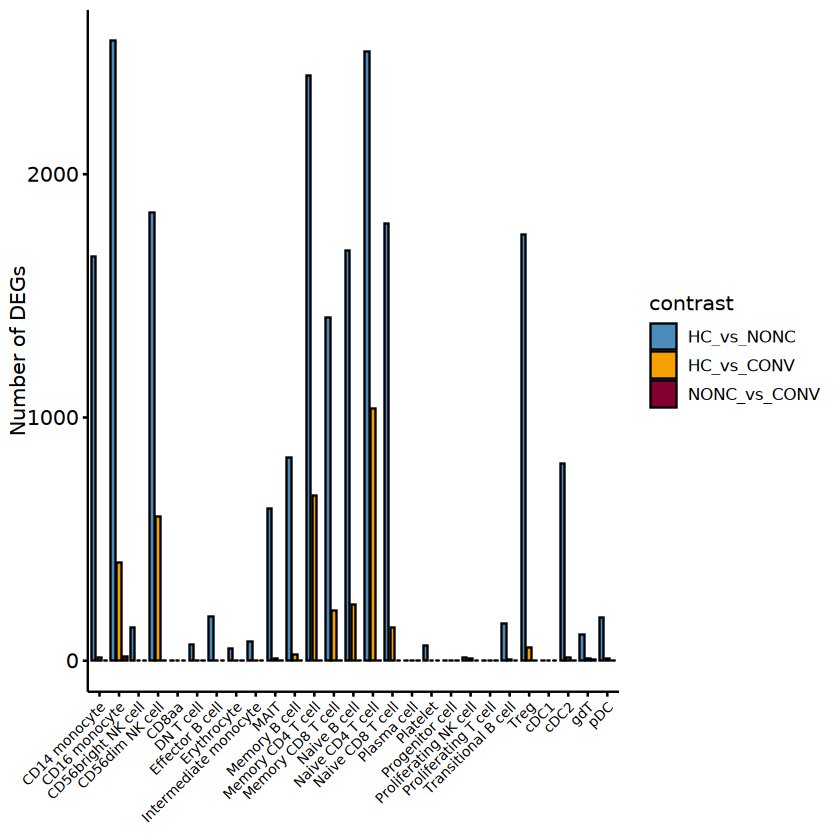

In [61]:
conv_nonv_colors <- c("#4C8CBD", "#F59F00", "#840032")
#
p1 <- deg_counts %>%
  ggbarplot(
    x = "cell_type", y = "deg_counts", legend = "right", # yscale = "log10",
    xlab = "", ylab = "Number of DEGs", position = position_dodge(0.9),
    fill = "contrast", palette = conv_nonv_colors
  ) +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 8))
p1
ggsave(file.path(fig_path, paste0(proj_name, "deg_counts.pdf")),
  width = 6, height = 5
)

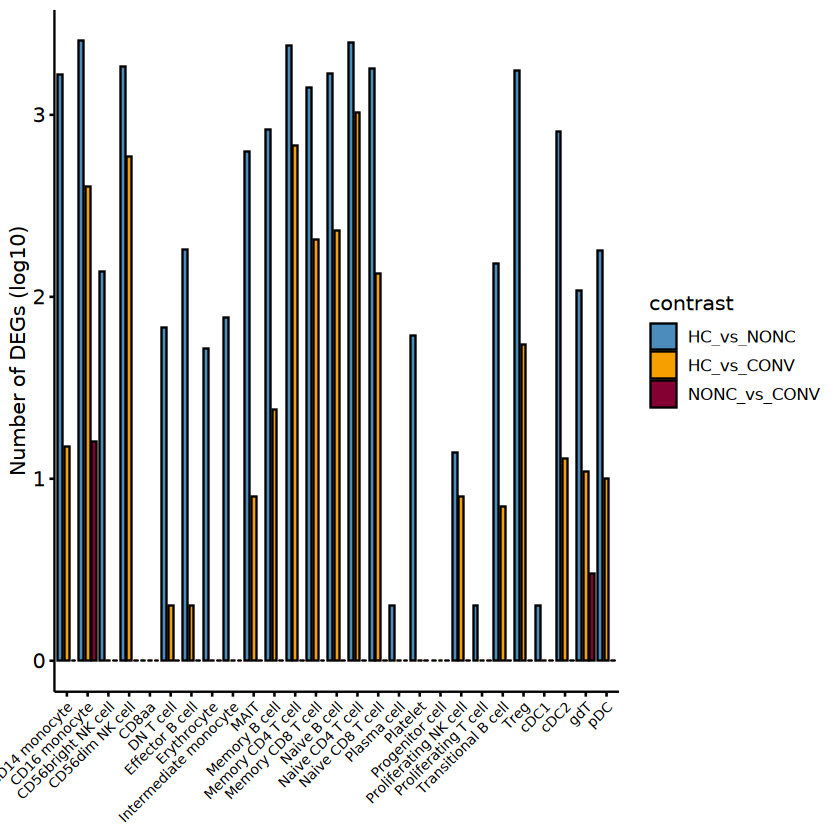

In [64]:
conv_nonv_colors <- c("#4C8CBD", "#F59F00", "#840032")
#
p1 <- deg_counts %>%
  ggbarplot(
    x = "cell_type", y = "log_n", legend = "right", # yscale = "log10",
    xlab = "", ylab = "Number of DEGs (log10)",
    position = position_dodge(), fill = "contrast", palette = conv_nonv_colors
  ) +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 8))
p1
ggsave(file.path(fig_path, paste0(proj_name, "deg_counts_log10.pdf")),
  width = 6, height = 5
)

### plot Fig S4C
- logfold correlation 

In [18]:
res_conv_nonc_hc_comb %>% head()

cell_type,contrast,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,qvalue,sig,model_converged
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
CD14 monocyte,ALTRA_healthy_vs_converter,A1BG,926.0493,-0.20237649,0.14339853,-1.4112871,0.15815997,0.7841654,0.6823162,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAED1,411.9805,0.09416767,0.07264262,1.2963143,0.19486722,0.8098046,0.7046254,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAGAB,210.4030,0.03309583,0.05800993,0.5705201,0.56832499,0.9360090,0.8144381,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAK1,1004.7405,-0.25112545,0.12010300,-2.0909174,0.03653547,0.6664367,0.5798784,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMDC,215.8142,0.01708434,0.07680860,0.2224274,0.82398120,0.9767676,0.8499028,ns,NA
CD14 monocyte,ALTRA_healthy_vs_converter,AAMP,546.8380,-0.08753289,0.05956360,-1.4695701,0.14167821,0.7785778,0.6774544,ns,NA


In [19]:
conv_nonc_hc_logfc <- res_conv_nonc_hc_comb %>%
  mutate(contrast = str_replace_all(
    contrast,
    c(ALTRA_healthy = "HC", non_converter = "NONC", early_RA = "ERA", converter = "CONV")
  )) %>%
  mutate(contrast = factor(contrast, levels = c("HC_vs_NONC", "HC_vs_CONV", "NONC_vs_CONV"))) %>%
  pivot_wider(id_cols = c("cell_type", "gene"), names_from = "contrast", values_from = "log2FoldChange") %>%
  filter(!is.na(HC_vs_CONV) & !is.na(HC_vs_NONC) & !is.na(NONC_vs_CONV))
conv_nonc_hc_logfc %>% head()

cell_type,gene,HC_vs_CONV,HC_vs_NONC,NONC_vs_CONV
<chr>,<chr>,<dbl>,<dbl>,<dbl>
CD14 monocyte,A1BG,-0.20237649,-0.197912526,0.0001015948
CD14 monocyte,AAED1,0.09416767,-0.003861629,-0.0376067603
CD14 monocyte,AAGAB,0.03309583,0.036688567,-0.0041666183
CD14 monocyte,AAK1,-0.25112545,-0.045970657,0.0451333016
CD14 monocyte,AAMDC,0.01708434,-0.032418109,-0.0877742218
CD14 monocyte,AAMP,-0.08753289,-0.134484954,-0.0240641970


In [26]:
conv_nonc_hc_logfc %>% filter(abs(HC_vs_CONV) > 5 | abs(HC_vs_NONC) > 5)

cell_type,gene,HC_vs_CONV,HC_vs_NONC,NONC_vs_CONV
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Erythrocyte,HBG2,5.922616,2.788465,-1.4934195
Plasma cell,IGHV1-2,-4.840855,-5.105329,-0.6420566
Plasma cell,IGHV3-74,19.879656,-1.784121,-7.0818905
Plasma cell,IGKV1-16,11.564867,3.827430,-0.2023238


In [42]:
# load the color scheme
l2_colors <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/AIFI_Reference_L3_L2_L1_color_hexcode.csv") %>%
  select(Level2, Level2_color) %>%
  distinct(Level2, .keep_all = TRUE) %>%
  arrange(Level2) %>%
  rename("Level2" = "cell_type")
l2_colors <- conv_nonc_hc_logfc %>%
  distinct(cell_type) %>%
  left_join(l2_colors, by = "cell_type")
l2_colors %>% head()

New names:
• `` -> `...1`
Rows: 71 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): label, color, annotation_color, Level1, Level2, Level2_color, Level...
dbl (4): ...1, xpos, xmin, xmax

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cell_type,Level2_color
<chr>,<chr>
CD14 monocyte,#DB6318
CD16 monocyte,#EE9C67
CD56bright NK cell,#FF7F55
CD56dim NK cell,#BA4B32
DN T cell,#656E68
Effector B cell,#CCA39F


Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


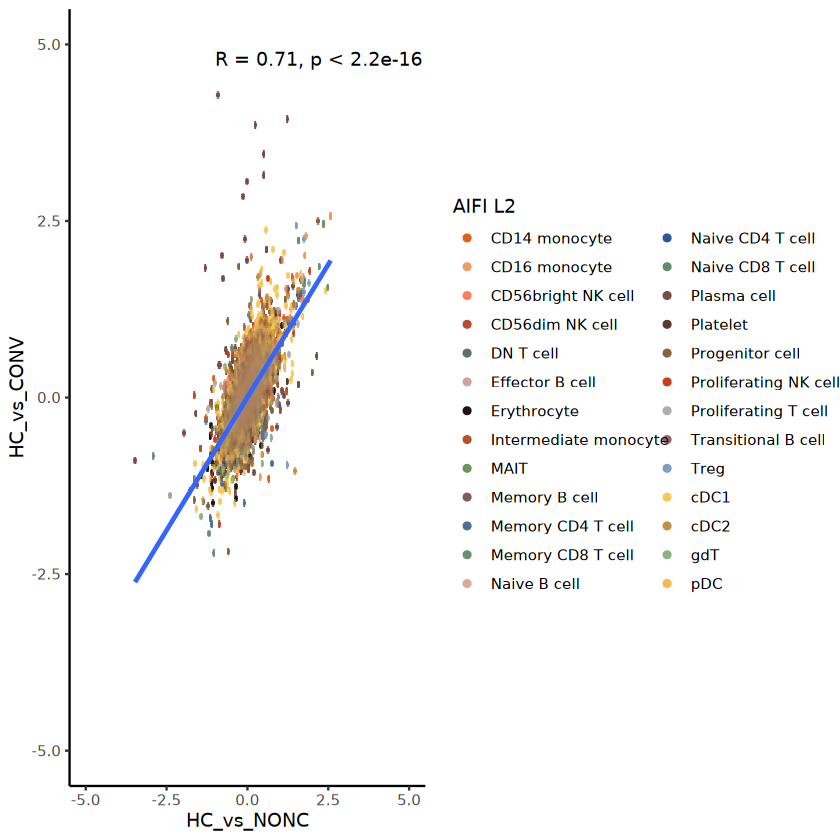

In [56]:
conv_nonc_hc_logfc %>%
  ggplot(aes(x = HC_vs_NONC, y = HC_vs_CONV)) +
  scattermore::geom_scattermore(aes(color = cell_type), pointsize = 3) +
  stat_smooth(
    method = "lm",
    formula = y ~ x,
    geom = "smooth"
  ) +
  #  geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+
  ggpubr::stat_cor(method = "spearman", label.x = -1) +
  theme_classic() +
  guides(color = guide_legend(title = "AIFI L2")) +
  xlim(-5, 5) +
  ylim(-5, 5) +
  scale_color_manual(values = l2_colors$Level2_color)
ggsave(file.path(fig_path, paste0(proj_name, "logfc_scatter.pdf")),
  width = 8, height = 4
)

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


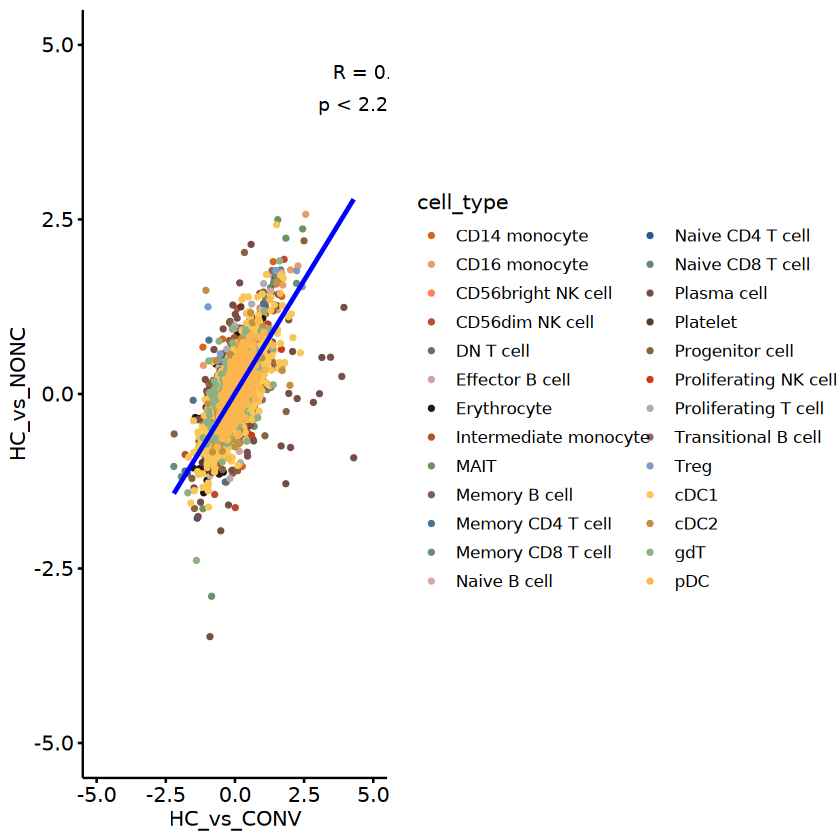

In [43]:
conv_nonc_hc_logfc %>%
  ggscatter(
    x = "HC_vs_CONV", y = "HC_vs_NONC", color = "cell_type",
    legend = "right", palette = l2_colors$Level2_color, size = 1,
    add = "reg.line", # Add regressin line
    add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
    conf.int = TRUE, # Add confidence interval
    cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
    cor.coeff.args = list(method = "spearman", label.x = 3, label.sep = "\n")
  ) +
  xlim(-5, 5) + ylim(-5, 5)
ggsave(file.path(fig_path, paste0(proj_name, "logfc_scatter.pdf")),
  width = 8, height = 4
)

In [154]:
conv_nonconv_hc_cor <- conv_nonc_hc_logfc %>%
  group_by(cell_type) %>%
  cor_test(
    vars = c("HC_vs_CONV", "HC_vs_NONC", "NONC_vs_CONV"),
    method = "spearman"
  ) %>%
  mutate(comparison = paste(var1, var2, sep = "_cor_"))

In [163]:
conv_nonconv_hc_cor %>% distinct(comparison)

comparison
<chr>
HC_vs_CONV_cor_HC_vs_CONV
HC_vs_CONV_cor_HC_vs_NONC
HC_vs_CONV_cor_NONC_vs_CONV
HC_vs_NONC_cor_HC_vs_CONV
HC_vs_NONC_cor_HC_vs_NONC
HC_vs_NONC_cor_NONC_vs_CONV
NONC_vs_CONV_cor_HC_vs_CONV
NONC_vs_CONV_cor_HC_vs_NONC
NONC_vs_CONV_cor_NONC_vs_CONV


In [164]:
conv_nonconv_hc_cor_rho <- conv_nonconv_hc_cor %>%
  filter(comparison %in% c(
    "HC_vs_CONV_cor_HC_vs_NONC", "HC_vs_NONC_cor_NONC_vs_CONV",
    "HC_vs_CONV_cor_NONC_vs_CONV"
  )) %>%
  pivot_wider(id_cols = "cell_type", names_from = "comparison", values_from = "cor")
conv_nonconv_hc_cor_rho %>% head()

cell_type,HC_vs_CONV_cor_HC_vs_NONC,HC_vs_CONV_cor_NONC_vs_CONV,HC_vs_NONC_cor_NONC_vs_CONV
<chr>,<dbl>,<dbl>,<dbl>
CD14 monocyte,0.64,-0.100,0.52
CD16 monocyte,0.77,-0.120,0.39
CD56bright NK cell,0.66,-0.330,0.28
CD56dim NK cell,0.83,-0.096,0.29
DN T cell,0.69,-0.420,0.19
Effector B cell,0.69,-0.310,0.22


In [ ]:
# add deseq noamrlized count to the se objects
crox_norm <- addNormcountsList(subset_pb_se_crox, crox_deseq,
  method = "vst",
  assay_name = "normalized_counts"
)

In [ ]:
crox_norm %>% saveRDS(file.path(output_path, paste0(proj_name, "_norm_counts_object.rds")))

### upload results to collab space

In [1]:
hise::cacheFiles(list("d9ced8ed-5954-4347-91e0-2415eed5d085"))

[1] "downloading fileID d9ced8ed-5954-4347-91e0-2415eed5d085"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/d9ced8ed-5954-4347-91e0-2415eed5d085/revision/ALTRA_scRNA_AIFI_L2_141samples__psedobulk_SE_object_list.rds"

In [15]:
# upload data
hise::uploadFiles(
  files = list("/home/workspace/data/ALTRA_manusript/Table_S19_conv_nonc_hc_degs.csv"),
  destination = "revision/",
  studySpaceId = "223de760-9624-45bd-aefe-ca24c75b1800",
  title = "ALTRA scRNA AIFI_L2 conv nonc deg results",
  inputFileIds = list("d9ced8ed-5954-4347-91e0-2415eed5d085")
)

[1] "Retrying..."


$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "f70fd21e-cf8e-47ce-9d72-49ee7f6948ce"

$ProcessId
[1] "7e5563c3-72e7-4eb9-98c4-d9cd4e6a0813"

$WorkflowId
[1] "4043d761-eeb3-461f-8270-9d926070c1fd"

$FileIds
$FileIds[[1]]
[1] "8e2e989f-fe7c-40e0-bc46-b40a0762ba25"

In [51]:
# upload data
hise::uploadFiles(
  files = list("/home/workspace/data/ALTRA_manusript/ALTRA_L2_baseline_crox__conv_nonv_deseq2_norm_counts.rds"),
  destination = "revision/",
  studySpaceId = "223de760-9624-45bd-aefe-ca24c75b1800",
  title = "ALTRA scRNA AIFI_L2 conv nonc deseq2 normalized counts",
  inputFileIds = list("d9ced8ed-5954-4347-91e0-2415eed5d085")
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "285a74bc-dd8e-4f5d-8532-1f50a04c3a2b"

$ProcessId
[1] "b63eab9b-52ac-4ea8-a65a-f1629ffbe437"

$WorkflowId
[1] "321177d9-5882-406a-80e6-79e3be2ce935"

$FileIds
$FileIds[[1]]
[1] "eb8b51a0-821a-4ac3-82e8-facdcea74c25"